In [3]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
import numpy as np
import time

X_pc_full_final = np.load(r"C:\Users\user\Downloads\GSE148375_clean\pc_input_matrix.npy")

import json
with open(r"C:\Users\user\Downloads\GSE148375_clean\pc_col_names.json") as f:
    col_names_final = json.load(f)

print("Input shape:", X_pc_full_final.shape)

# try stricter alpha — fewer edges survive, algorithm terminates faster
start = time.time()
cg = pc(
    data=X_pc_full_final,
    alpha=0.001,        # <-- much stricter than 0.05
    indep_test=fisherz,
    stable=True,
    uc_rule=0,
    uc_priority=2,
    mvpc=False,
    verbose=False,
    show_progress=True
)
elapsed = time.time() - start
print(f"Completed in {elapsed:.1f} seconds")
print("Nodes:", len(cg.G.nodes))


Input shape: (3348, 65)


Depth=12, working on node 64: 100%|██████████| 65/65 [00:00<00:00, 707.08it/s]


Completed in 11.3 seconds
Nodes: 65


In [4]:
import numpy as np
import pandas as pd

# get adjacency matrix from the result
# cg.G.graph[i,j]=1 and cg.G.graph[j,i]=-1 means i→j
# cg.G.graph[i,j]=cg.G.graph[j,i]=-1 means i---j (undirected)
adj = cg.G.graph  # shape (65, 65)

print("Adjacency matrix shape:", adj.shape)
print("Column names:", len(col_names_final))

# find smoking_status index
smoking_idx = col_names_final.index("smoking_status")
print("smoking_status index:", smoking_idx)

# summarize edges found
n_directed = 0
n_undirected = 0
edges = []

for i in range(len(col_names_final)):
    for j in range(i+1, len(col_names_final)):
        if adj[i,j] == -1 and adj[j,i] == 1:
            edges.append((col_names_final[i], col_names_final[j], "→"))
            n_directed += 1
        elif adj[i,j] == 1 and adj[j,i] == -1:
            edges.append((col_names_final[j], col_names_final[i], "→"))
            n_directed += 1
        elif adj[i,j] == -1 and adj[j,i] == -1:
            edges.append((col_names_final[i], col_names_final[j], "---"))
            n_undirected += 1

print(f"Total edges: {len(edges)} ({n_directed} directed, {n_undirected} undirected)")
print("\nEdges involving smoking_status:")
for e in edges:
    if "smoking_status" in e:
        print(f"  {e[0]} {e[2]} {e[1]}")

Adjacency matrix shape: (65, 65)
Column names: 65
smoking_status index: 64
Total edges: 30 (26 directed, 4 undirected)

Edges involving smoking_status:
  exm-rs16982520-131_T_F_1990489099 → smoking_status
  exm609218-0_B_F_1918575531 → smoking_status
  smoking_status → exm236098-0_T_R_1918982506
  exm100944-0_B_R_1921482882 → smoking_status
  exm1421650-0_T_F_1923324725 → smoking_status
  exm317474-0_B_F_1922239353 → smoking_status
  exm1379120-0_T_F_1921625489 → smoking_status
  exm2277017-0_T_R_1989215336 → smoking_status
  exm782555-0_B_R_1922302526 → smoking_status
  exm759751-0_T_R_1922412944 → smoking_status
  exm777999-0_B_F_1922426645 → smoking_status
  exm1245580-0_B_F_2060131617 → smoking_status
  exm418184-0_B_R_1923021066 → smoking_status


In [5]:
import networkx as nx

# build directed graph from adjacency matrix
G_directed = nx.DiGraph()
G_directed.add_nodes_from(col_names_final)

for i in range(len(col_names_final)):
    for j in range(len(col_names_final)):
        if adj[i,j] == -1 and adj[j,i] == 1:
            G_directed.add_edge(col_names_final[i], col_names_final[j])
        elif adj[i,j] == -1 and adj[j,i] == -1:
            # undirected edge — add both directions for reachability
            G_directed.add_edge(col_names_final[i], col_names_final[j])
            G_directed.add_edge(col_names_final[j], col_names_final[i])

# biological pruning:
# remove any edge pointing FROM smoking_status TO a SNP (biologically impossible)
reverse_edges = [(u, v) for u, v in G_directed.edges()
                 if u == "smoking_status" and v != "smoking_status"]
print("Removing reverse edges:", reverse_edges)
G_directed.remove_edges_from(reverse_edges)

# keep only nodes that have a directed path TO smoking_status
ancestors = nx.ancestors(G_directed, "smoking_status")
ancestors.add("smoking_status")
print("Nodes with path to smoking_status:", len(ancestors))

# build final pruned graph
G_final = G_directed.subgraph(ancestors).copy()
print("Final graph nodes:", G_final.number_of_nodes())
print("Final graph edges:", G_final.number_of_edges())

# list final edges
print("\nFinal causal network edges:")
for u, v in G_final.edges():
    print(f"  {u} → {v}")

Removing reverse edges: [('smoking_status', 'exm236098-0_T_R_1918982506')]
Nodes with path to smoking_status: 14
Final graph nodes: 14
Final graph edges: 14

Final causal network edges:
  exm609218-0_B_F_1918575531 → smoking_status
  exm1421650-0_T_F_1923324725 → smoking_status
  exm1325181-0_T_F_1918780387 → exm759751-0_T_R_1922412944
  exm-rs16982520-131_T_F_1990489099 → smoking_status
  exm1379120-0_T_F_1921625489 → smoking_status
  exm777999-0_B_F_1922426645 → smoking_status
  exm759751-0_T_R_1922412944 → exm1325181-0_T_F_1918780387
  exm759751-0_T_R_1922412944 → smoking_status
  exm418184-0_B_R_1923021066 → smoking_status
  exm100944-0_B_R_1921482882 → smoking_status
  exm317474-0_B_F_1922239353 → smoking_status
  exm1245580-0_B_F_2060131617 → smoking_status
  exm2277017-0_T_R_1989215336 → smoking_status
  exm782555-0_B_R_1922302526 → smoking_status


Node chromosomes: {'exm609218-0_B_F_1918575531': '7', 'exm1421650-0_T_F_1923324725': '19', 'exm1325181-0_T_F_1918780387': '17', 'exm-rs16982520-131_T_F_1990489099': '20', 'exm1379120-0_T_F_1921625489': '18', 'exm777999-0_B_F_1922426645': '9', 'exm759751-0_T_R_1922412944': '9', 'exm418184-0_B_R_1923021066': '4', 'smoking_status': 'phenotype', 'exm100944-0_B_R_1921482882': '1', 'exm317474-0_B_F_1922239353': '3', 'exm1245580-0_B_F_2060131617': '16', 'exm2277017-0_T_R_1989215336': '1', 'exm782555-0_B_R_1922302526': '9'}


C:\Users\user\AppData\Local\Temp\ipykernel_8200\3787929199.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_chroms))


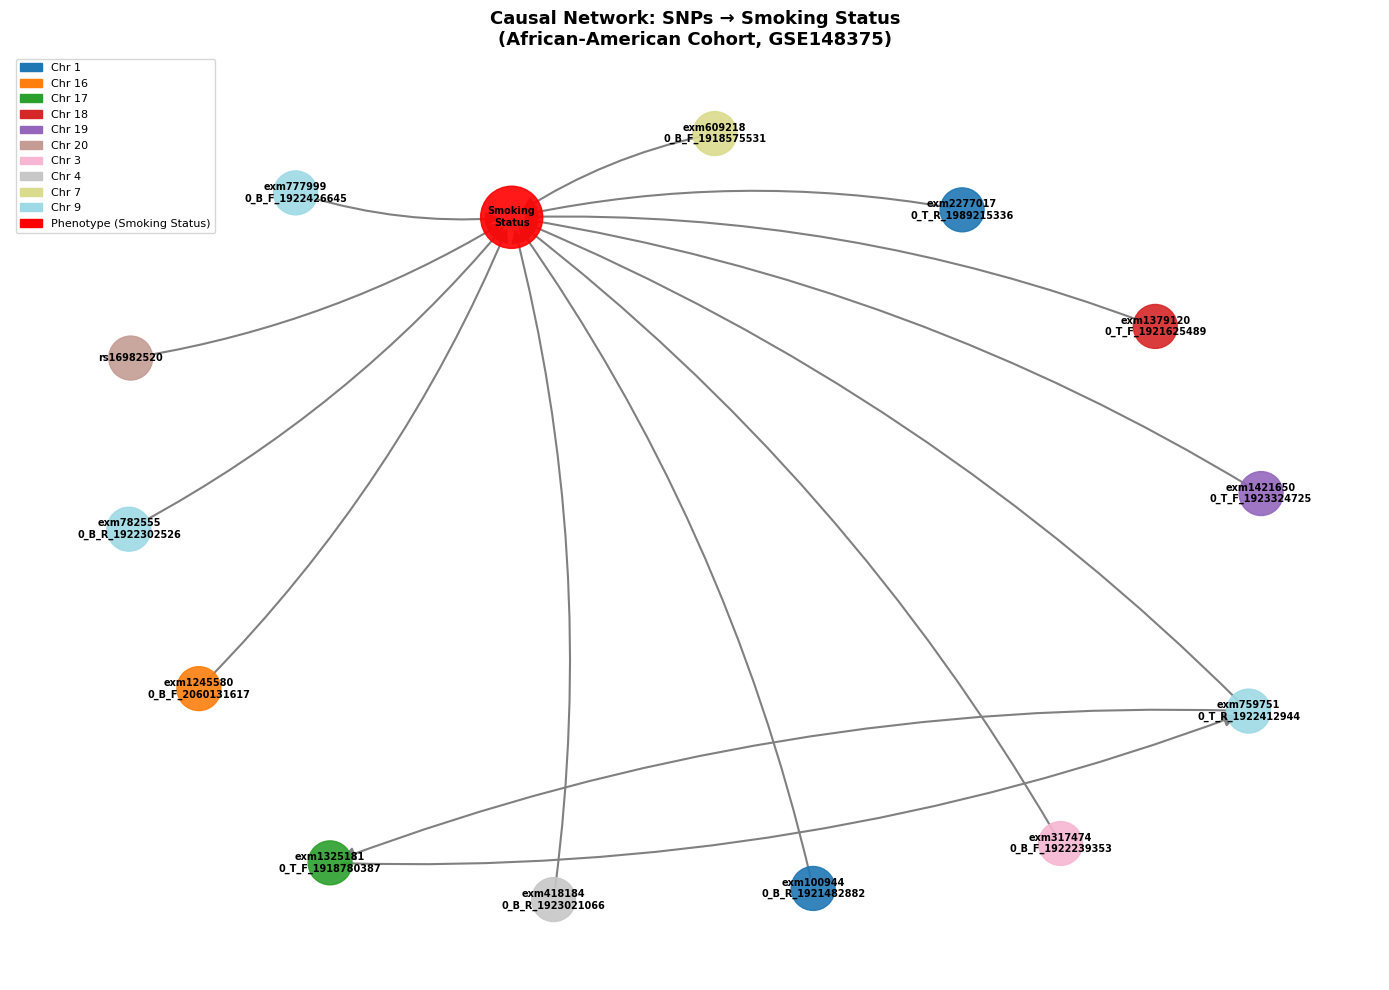

Saved causal network figure.


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd

# get chromosome info for the final nodes
manifest_path = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"
manifest_df = pd.read_csv(manifest_path, skiprows=7, low_memory=False)

import re
def strip_address_suffix(probe_id):
    return re.sub(r'_\d+$', '', probe_id)

manifest_df["core_name"] = manifest_df["IlmnID"].map(strip_address_suffix)
chr_lookup = manifest_df.set_index("core_name")["Chr"]

node_chromosomes = {}
for node in G_final.nodes():
    if node == "smoking_status":
        node_chromosomes[node] = "phenotype"
    else:
        core = strip_address_suffix(node)
        chrom = chr_lookup.get(core, "?")
        node_chromosomes[node] = str(chrom)

print("Node chromosomes:", node_chromosomes)

# assign colors per chromosome
unique_chroms = sorted(set(v for v in node_chromosomes.values() if v != "phenotype"))
cmap = plt.cm.get_cmap("tab20", len(unique_chroms))
chrom_color = {chrom: cmap(i) for i, chrom in enumerate(unique_chroms)}
chrom_color["phenotype"] = "red"

node_colors = [chrom_color[node_chromosomes[n]] for n in G_final.nodes()]
node_sizes = [2000 if n == "smoking_status" else 1000 for n in G_final.nodes()]

# short labels for readability
def short_label(probe_id):
    if probe_id == "smoking_status":
        return "Smoking\nStatus"
    if probe_id.startswith("exm-rs"):
        rs = probe_id.split("-")[1]
        return rs
    parts = probe_id.split("-")
    return parts[0] + "\n" + parts[1] if len(parts) > 1 else probe_id

node_labels = {n: short_label(n) for n in G_final.nodes()}

# draw
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_final, seed=42, k=2.5)

nx.draw_networkx_nodes(G_final, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G_final, pos, labels=node_labels,
                        font_size=7, font_weight="bold")
nx.draw_networkx_edges(G_final, pos, edge_color="gray",
                       arrows=True, arrowsize=20,
                       connectionstyle="arc3,rad=0.1",
                       width=1.5)

# legend for chromosomes
legend_patches = [
    mpatches.Patch(color=chrom_color[c], label=f"Chr {c}")
    for c in unique_chroms
]
legend_patches.append(mpatches.Patch(color="red", label="Phenotype (Smoking Status)"))
plt.legend(handles=legend_patches, loc="upper left", fontsize=8)

plt.title("Causal Network: SNPs → Smoking Status\n(African-American Cohort, GSE148375)",
          fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig(r"C:\Users\user\Downloads\GSE148375_clean\causal_network_african_american.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved causal network figure.")

In [7]:
import pandas as pd
import re
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"

# the 13 SNPs in our final network (from the edges we printed earlier)
network_snps = [
    "exm-rs16982520-131_T_F_1990489099",
    "exm609218-0_B_F_1918575531",
    "exm100944-0_B_R_1921482882",
    "exm1421650-0_T_F_1923324725",
    "exm317474-0_B_F_1922239353",
    "exm1379120-0_T_F_1921625489",
    "exm2277017-0_T_R_1989215336",
    "exm782555-0_B_R_1922302526",
    "exm759751-0_T_R_1922412944",
    "exm777999-0_B_F_1922426645",
    "exm1245580-0_B_F_2060131617",
    "exm418184-0_B_R_1923021066",
    "exm1325181-0_T_F_1918780387"
]

# reload manifest if needed
manifest_path = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"
manifest_df = pd.read_csv(manifest_path, skiprows=7, low_memory=False)

def strip_address_suffix(probe_id):
    return re.sub(r'_\d+$', '', probe_id)

manifest_df["core_name"] = manifest_df["IlmnID"].map(strip_address_suffix)
position_lookup = manifest_df.set_index("core_name")[["Chr", "MapInfo", "Name"]]

# build annotation table
rows = []
for pid in network_snps:
    core = strip_address_suffix(pid)
    match = position_lookup.loc[core] if core in position_lookup.index else None
    if match is not None:
        rows.append({
            "probe_id": pid,
            "core_name": core,
            "Chr": match["Chr"],
            "Position_bp": int(match["MapInfo"]) if pd.notna(match["MapInfo"]) else None,
            "Illumina_Name": match["Name"]
        })
    else:
        rows.append({"probe_id": pid, "core_name": core, "Chr": "?", "Position_bp": None, "Illumina_Name": "?"})

annot_df = pd.DataFrame(rows)
print(annot_df[["probe_id", "Chr", "Position_bp", "Illumina_Name"]])

                             probe_id Chr  Position_bp   Illumina_Name
0   exm-rs16982520-131_T_F_1990489099  20     57758720  exm-rs16982520
1          exm609218-0_B_F_1918575531   7     22985282       exm609218
2          exm100944-0_B_R_1921482882   1    152329460       exm100944
3         exm1421650-0_T_F_1923324725  19      9074017      exm1421650
4          exm317474-0_B_F_1922239353   3     50312822       exm317474
5         exm1379120-0_T_F_1921625489  18     21530071      exm1379120
6         exm2277017-0_T_R_1989215336   1    202399880      exm2277017
7          exm782555-0_B_R_1922302526   9    130206472       exm782555
8          exm759751-0_T_R_1922412944   9     90584110       exm759751
9          exm777999-0_B_F_1922426645   9    123914765       exm777999
10        exm1245580-0_B_F_2060131617  16     58320066      exm1245580
11         exm418184-0_B_R_1923021066   4    110394162       exm418184
12        exm1325181-0_T_F_1918780387  17     40831590      exm1325181


In [9]:
! pip install requests

  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached idna-3.18-py3-none-any.whl (65 kB)
Using cached urllib3-2.7.0-py3-none-any.whl (131 kB)

   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   -------- ------------------------------- 1/5 [idna]
   -------- ------------------------------- 1/5 [idna]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   -------------------------------- ------- 4/5 [requests]
   -------------------------------- ------- 4/5 [requests]
   ---------------------------------------- 5/5 [requests]



In [11]:
import requests
import time
import pandas as pd
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"

def get_gene_ensembl(chrom, pos, window=50000):
    """Query Ensembl REST API for genes overlapping chr:pos (GRCh37)"""
    url = f"https://grch37.rest.ensembl.org/overlap/region/human/{chrom}:{pos-window}-{pos+window}"
    params = {"feature": "gene", "content-type": "application/json"}
    try:
        r = requests.get(url, params=params, timeout=15)
        if r.status_code != 200:
            return "API error"
        genes = r.json()
        if not genes:
            return "intergenic"
        # filter for protein_coding genes first, fallback to all
        coding = [g for g in genes if g.get("biotype") == "protein_coding"]
        targets = coding if coding else genes
        names = list(set(g.get("external_name", g.get("gene_id", "?")) for g in targets))
        return " | ".join(names[:5])
    except Exception as e:
        return f"error: {e}"

annot_df = pd.read_csv(os.path.join(out_dir, "network_snp_annotations.csv"))

print("Querying Ensembl GRCh37 REST API...")
for i, row in annot_df.iterrows():
    chrom = str(row["Chr"])
    pos = int(row["Position_bp"])
    gene = get_gene_ensembl(chrom, pos)
    annot_df.at[i, "gene_annotation"] = gene
    print(f"Chr{chrom}:{pos} | {row['Illumina_Name']:<25} | {gene}")
    time.sleep(0.5)

annot_df.to_csv(os.path.join(out_dir, "network_snp_annotations.csv"), index=False)
print("\nSaved.")

Querying Ensembl GRCh37 REST API...
Chr20:57758720 | exm-rs16982520            | ZNF831
Chr7:22985282 | exm609218                 | FAM126A
Chr1:152329460 | exm100944                 | FLG | FLG2
Chr19:9074017 | exm1421650                | MUC16
Chr3:50312822 | exm317474                 | TUSC2 | GNAI2 | NAT6 | HYAL2 | HYAL3
Chr18:21530071 | exm1379120                | LAMA3 | TTC39C
Chr1:202399880 | exm2277017                | PPP1R12B
Chr9:130206472 | exm782555                 | SLC2A8 | RPL12 | LRSAM1 | ZNF79
Chr9:90584110 | exm759751                 | CDK20
Chr9:123914765 | exm777999                 | CNTRL | RAB14
Chr16:58320066 | exm1245580                | PRSS54 | GINS3 | CCDC113
Chr4:110394162 | exm418184                 | SEC24B
Chr17:40831590 | exm1325181                | TUBG2 | PLEKHH3 | CCR10 | EZH1 | CNTNAP1

Saved.
